# Usage of PySpark SQL

In [9]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
                     .appName("Analyzing an unknown article.")
                     .getOrCreate())


In [10]:
spark

In [11]:
sc = spark.sparkContext

In [12]:
## documentation
spark.read??

In [13]:
file_path = r'article_source.txt'

In [14]:
article = spark.read.text(file_path)

In [15]:
article

DataFrame[value: string]

In [16]:
article.printSchema()

root
 |-- value: string (nullable = true)



In [17]:
article.select(article.value)

DataFrame[value: string]

In [18]:
article.show(5, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                                                                                             |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Welcome to New Music Friday, NPR Music's podcast dedicated to sharing th

In [19]:
from pyspark.sql.functions import col

In [20]:

article.select(article.value)
article.select(article['value'])
article.select(col('value'))
article.select('value')

DataFrame[value: string]

In [21]:
from pyspark.sql.functions import col, split

lines = article.select(
    split(col('value'), " ").alias('line')
)

In [22]:
lines.printSchema()

root
 |-- line: array (nullable = true)
 |    |-- element: string (containsNull = false)



In [23]:
lines.show(5, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|line                                                                                                                                                                                                                                                                                                                                                                    |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [24]:
lines

DataFrame[line: array<string>]

In [25]:
from pyspark.sql.functions import explode

words = lines.select(explode(col("line")).alias('word'))

In [26]:
words.printSchema()

root
 |-- word: string (nullable = false)



In [27]:
from pyspark.sql.functions import lower

words_lower = words.select(lower(col("word")).alias('word_lower'))

In [28]:
words_lower.show(10)

+----------+
|word_lower|
+----------+
|   welcome|
|        to|
|       new|
|     music|
|   friday,|
|       npr|
|   music's|
|   podcast|
| dedicated|
|        to|
+----------+
only showing top 10 rows


In [29]:
from pyspark.sql.functions import regexp_extract

words_clean = words_lower.select(
    regexp_extract(col("word_lower"), r"(\W+)?([a-z]+)", 2).alias("word_clean")
)

In [30]:
words_clean.show(10)

+----------+
|word_clean|
+----------+
|   welcome|
|        to|
|       new|
|     music|
|    friday|
|       npr|
|     music|
|   podcast|
| dedicated|
|        to|
+----------+
only showing top 10 rows


In [31]:
words_nonull = words_clean.where(col("word_clean") != "")

words_nonull.show(100)

+----------+
|word_clean|
+----------+
|   welcome|
|        to|
|       new|
|     music|
|    friday|
|       npr|
|     music|
|   podcast|
| dedicated|
|        to|
|   sharing|
|       the|
|      best|
|    albums|
|       out|
|      each|
|      week|
|        we|
|    listen|
|        to|
|    dozens|
|        of|
|       new|
|  releases|
|        in|
|   advance|
|  identify|
|       the|
|      ones|
|        we|
|     think|
|       you|
|      need|
|        to|
|      hear|
|       and|
| highlight|
|       our|
|  favorite|
|      five|
|        in|
|         a|
|     brisk|
|       mix|
|        of|
|     clips|
|   context|
|       and|
|commentary|
|       the|
|   podcast|
|        is|
|    hosted|
|        by|
|       npr|
|     music|
|   stephen|
|  thompson|
|       and|
|      each|
|   episode|
|  features|
|         a|
|    member|
|        of|
|       the|
|       npr|
|     music|
|   network|
|        of|
|    public|
|     radio|
|  stations|
|      this|

In [32]:
groups = words_nonull.groupBy(col("word_clean"))

In [33]:
groups

GroupedData[grouping expressions: [word_clean], value: [word_clean: string], type: GroupBy]

In [34]:
counts = groups.count()

In [35]:
counts.orderBy('count', ascending=False).show(10)

+----------+-----+
|word_clean|count|
+----------+-----+
|       the|   29|
|     music|   15|
|        of|   15|
|       and|   11|
|        to|   10|
|        in|    8|
|       you|    7|
|       npr|    7|
|       new|    6|
|    albums|    5|
+----------+-----+
only showing top 10 rows


In [42]:
import pyspark.sql.functions as F

counts = (
    spark.read.text(file_path)
     .select(F.split(F.col('value'), ' ').alias('line'))
     .select(F.explode(F.col('line')).alias('word'))
     .select(F.lower(F.col('word')).alias('word'))
     .select(F.regexp_extract(F.col('word'), r"(\W+)?([a-z]+)", 2).alias('word'))
     .where(F.col('word') != "")
     .groupby('word')
     .count()
)

In [43]:
counts.show(10)

+----------+-----+
|      word|count|
+----------+-----+
|       art|    1|
|     still|    1|
|  stations|    1|
|     staff|    1|
| operation|    1|
|      dive|    1|
|   gillard|    1|
|    tienne|    1|
|hrishikesh|    1|
|production|    2|
+----------+-----+
only showing top 10 rows


## **In Class Exercise**

Then do the following:
1. Remove words with 3 or fewer letters
2. Return the top 5 words and their occurrence frequency
3. Produce a histogram of each letter in the alphabet ordered from highest to lowest frequency

In [44]:
counts_filtered = counts.where(F.length(F.col('word')) > 3)

In [56]:
counts_filtered.orderBy(F.col('count'), ascending=False).show(5)

+-------+-----+
|   word|count|
+-------+-----+
|  music|   15|
| albums|    5|
|podcast|    5|
| friday|    5|
|   riyl|    4|
+-------+-----+
only showing top 5 rows


In [57]:
letter_counts = (
    spark.read.text(file_path)
    .select(F.explode(F.split(F.col('value'), '')).alias('letter'))
    .select(F.lower(F.col('letter')).alias('letter'))
    .where(F.col('letter').rlike('^[a-z]$'))
    .groupby('letter')
    .count()
    .orderBy(F.col('count'), ascending=False)
)

letter_counts.show(26)

+------+-----+
|letter|count|
+------+-----+
|     e|  436|
|     a|  354|
|     i|  298|
|     o|  287|
|     s|  286|
|     t|  283|
|     r|  277|
|     n|  261|
|     l|  230|
|     h|  159|
|     d|  158|
|     c|  143|
|     u|  139|
|     m|  127|
|     p|   95|
|     y|   85|
|     g|   82|
|     f|   78|
|     w|   69|
|     b|   56|
|     k|   49|
|     v|   40|
|     j|   22|
|     z|   16|
|     x|   15|
|     q|    4|
+------+-----+



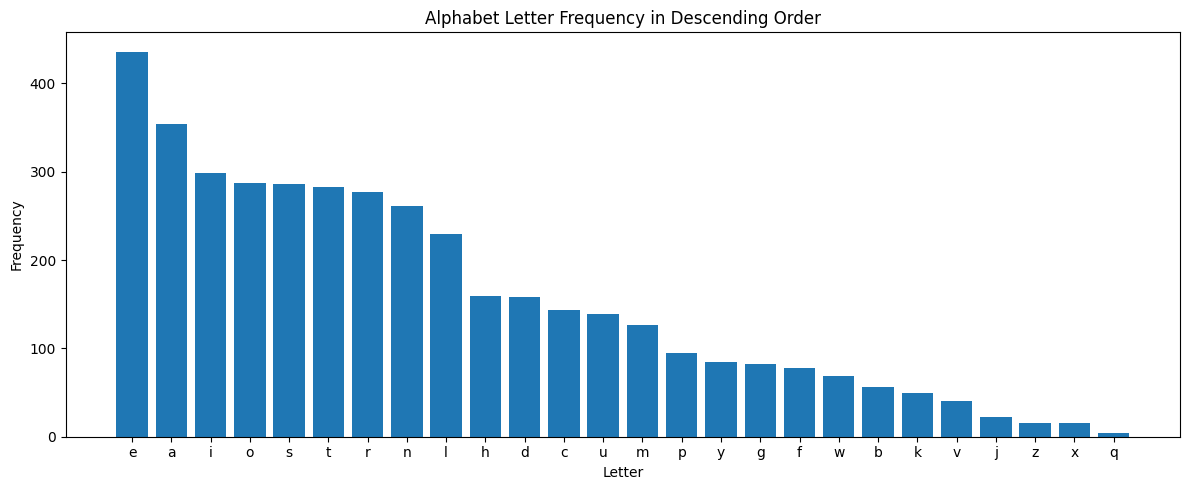

In [59]:
import matplotlib.pyplot as plt

df = letter_counts.toPandas()

plt.figure(figsize=(12, 5))
plt.bar(df['letter'], df['count'])
plt.xlabel('Letter')
plt.ylabel('Frequency')
plt.title('Alphabet Letter Frequency in Descending Order')
plt.tight_layout()
plt.show()